# CNN + LSTM Intrusion Detection System

**TII-SSRC-23 Network Traffic Classification — Multi-Dataset Edition**

This notebook trains a CNN+LSTM model to classify network flows as benign or malicious.
It supports multiple datasets so we can demonstrate results on more than one.

**How to use:**
1. Runtime → Change runtime type → **GPU (T4)**
2. Run all cells in order, OR
3. Edit the `DATASET_NAME` variable in the config cell to switch datasets

**Architecture:** 75 features → Conv1D(16) → BatchNorm → ReLU → LSTM(32) → Dense(64→32→8) → Softmax


## 1. Setup — Install dependencies and check GPU


In [1]:
# Install required packages
%pip install -q kagglehub imbalanced-learn


Note: you may need to restart the kernel to use updated packages.


In [1]:
import torch
import numpy as np
import pandas as pd
import os, time, json

# GPU check
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    print(f'GPU detected: {torch.cuda.get_device_name(0)}')
    print(f'CUDA version: {torch.version.cuda}')
else:
    print('No GPU — go to Runtime → Change runtime type → GPU')

print(f'PyTorch: {torch.__version__}')
print(f'Device: {device}')


No GPU — go to Runtime → Change runtime type → GPU
PyTorch: 2.11.0+cpu
Device: cpu


## 2. Configuration

**This is the only cell you need to edit when switching datasets.**

Pre-configured datasets:
- `tii-ssrc-23` — Original dataset (8 classes, our primary)
<!-- - `cicids-2017` — CIC-IDS-2017 (alternate, 14 attack types) -->
- `nsl-kdd` — NSL-KDD classic (5 classes)
- `custom` — Upload your own CSV via the Files panel


In [2]:
# EDIT THIS to switch between datasets
DATASET_NAME = 'custom'   # Options: 'tii-ssrc-23', 'nsl-kdd', 'custom'

# Training hyperparameters
MODE        = 'multiclass'     # 'multiclass' or 'binary'
EPOCHS      = 20
BATCH_SIZE  = 512
LEARNING_RATE = 0.003
WARMUP_EPOCHS = 2
PATIENCE    = 8
SEED        = 42

# For 'custom' dataset, set the path manually after uploading
CUSTOM_CSV_PATH = 'csv/data.csv'

DATASET_REGISTRY = {
    'tii-ssrc-23': {
        'kaggle_id': 'daniaherzalla/tii-ssrc-23',
        'description': 'TII-SSRC-23 — 8 traffic types (4 benign, 4 malicious)',
    },
    # 'cicids-2017': {
    #     'kaggle_id': 'cicdataset/cicids2017',
    #     'description': 'CIC-IDS-2017 — 14 attack types',
    # },
    'nsl-kdd': {
        'kaggle_id': 'hassan06/nslkdd',
        'description': 'NSL-KDD — Classic IDS benchmark, 5 classes',
    },
}

if DATASET_NAME != 'custom':
    print(f'Selected: {DATASET_NAME}')
    print(f'  → {DATASET_REGISTRY[DATASET_NAME]["description"]}')
else:
    print(f'Custom dataset: {CUSTOM_CSV_PATH}')


Custom dataset: csv/data.csv


## 3. Download dataset

Uses kagglehub to fetch the dataset. First run will download (~5GB for TII-SSRC-23, smaller for others).

**For Kaggle datasets:** You may need to authenticate. Upload your `kaggle.json` credentials file when prompted, or set them as environment variables.


In [3]:
import kagglehub
import glob

if DATASET_NAME == 'custom':
    csv_path = CUSTOM_CSV_PATH
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f'Custom CSV not found at {csv_path}. Upload it via the Files panel.')
else:
    info = DATASET_REGISTRY[DATASET_NAME]
    print(f'Downloading {info["kaggle_id"]}...')
    download_path = kagglehub.dataset_download(info['kaggle_id'])
    print(f'Downloaded to: {download_path}')

    # Find CSV files in the download
    csv_files = glob.glob(os.path.join(download_path, '**', '*.csv'), recursive=True)
    print(f'\nFound {len(csv_files)} CSV file(s):')
    for f in csv_files:
        size_mb = os.path.getsize(f) / (1024**2)
        print(f'  {size_mb:>8.1f} MB  {os.path.basename(f)}')

    if len(csv_files) == 1:
        csv_path = csv_files[0]
    else:
        # Pick the largest CSV (usually the main one)
        csv_path = max(csv_files, key=os.path.getsize)
        print(f'\nUsing largest: {os.path.basename(csv_path)}')

print(f'\nWill use: {csv_path}')


c:\Users\Aryan Agarwal\Desktop\VIT\3rd YEAR\Cryptography\cnn+ltsm deep learning\ids_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Will use: csv/data.csv


## 4. Inspect the dataset


In [22]:
# Peek at first 1000 rows to see structure
preview = pd.read_csv(csv_path, nrows=1000, low_memory=False)
print(f'Columns: {len(preview.columns)}')
print(f'First 5 columns: {list(preview.columns[:5])}')
print(f'Last 5 columns:  {list(preview.columns[-5:])}')
preview.head(3)


Columns: 86
First 5 columns: ['Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Dst Port']
Last 5 columns:  ['Idle Max', 'Idle Min', 'Label', 'Traffic Type', 'Traffic Subtype']


,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Total Fwd Packet,Total Bwd packets,...,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Traffic Type,Traffic Subtype
0,192.168.1.90-192.168.1.3-53930-64738-6,192.168.1.90,53930.0,192.168.1.3,64738,6.0,01/01/1970 07:41:46 AM,52601173.0,1701.0,1793.0,...,0.000000e+00,0.0,0.0,0.0,0.000000,0.0,0.0,Benign,Audio,Audio
1,192.168.1.3-192.168.1.90-64738-37700-6,192.168.1.3,64738.0,192.168.1.90,37700,6.0,01/01/1970 07:41:46 AM,119106942.0,36.0,57.0,...,3.416174e+06,19996926.0,14078617.0,5001511.0,1737.400069,5003516.0,5000449.0,Benign,Audio,Audio
2,192.168.1.3-192.168.1.90-22-40854-6,192.168.1.3,22.0,192.168.1.90,40854,6.0,01/01/1970 07:41:46 AM,5589.0,1.0,1.0,...,0.000000e+00,0.0,0.0,0.0,0.000000,0.0,0.0,Benign,Audio,Audio


In [ ]:
# NOTES FOR GIVEN BELOW FUNCTION "find_label_columns":

# There are type columns and label columns. Label columns contain the classification of whether attack or benign. Type columns contain the 
# attack type as well. For eg: DDOS type attack or Mirai botnet attacks can be classified by using the type_cols variable in the function defined.

# the line: 
# if type_col is None:
#     type_col = label_col

# means that if there are no attack type columns like DDOS, mirai botnet etc., then we can simply rely on the label column.

# Now this:

# feature_cols = [c for c in preview.columns 
#                 if c not in (label_col, type_col) and 'subtype' not in c.lower()]

# means that Identifyt creates a list of columns that:

# INCLUDED:

# All columns that are NOT:
# label_col
# type_col
# anything containing "subtype"

# EXAMPLE:

# If your dataset has:

# ['duration', 'protocol', 'src_bytes', 'label', 'attack_type']

# Then:

# label_col = 'label'
# type_col = 'attack_type'

# 👉 feature_cols becomes:

# ['duration', 'protocol', 'src_bytes']

In [113]:
# Identify label columns (works across datasets)
def find_label_columns(columns):
    label_col = None
    type_col = None
    for c in columns:
        cl = c.lower().strip()
        if cl == 'label' or cl == 'class':
            label_col = c
        elif 'type' in cl and 'sub' not in cl:
            type_col = c
        elif cl == 'attack_type' or cl == 'attack':
            type_col = c
    if type_col is None:
        type_col = label_col
    return label_col, type_col

label_col, type_col = find_label_columns(preview.columns)
print(f'Label column: {label_col}')
print(f'Type column:  {type_col}')

# Columns to exclude
EXCLUDE_COLS = {
    # Identifiers — no signal
    'Flow ID',
    'Src IP',
    'Dst IP',
    'Src Port',
    'Dst Port',
    'Timestamp',

    # Redundant — identical to other features in CICFlowMeter
    'Fwd Segment Size Avg',
    'Bwd Segment Size Avg',
    'Subflow Fwd Packets',
    'Subflow Bwd Packets',
    'Subflow Fwd Bytes',
    'Subflow Bwd Bytes',
    'Packet Length Variance',
    'Average Packet Size',
    'Fwd IAT Total',
    'Bwd IAT Total',  

    # Bulk features — near-zero in most flows, cause inf/nan issues
    'Fwd Bytes/Bulk Avg',
    'Fwd Packet/Bulk Avg',
    'Fwd Bulk Rate Avg',
    'Bwd Bytes/Bulk Avg',
    'Bwd Packet/Bulk Avg',
    'Bwd Bulk Rate Avg',
}

# Build feature list
feature_cols = [
    c for c in preview.columns
    if c not in (label_col, type_col)
    and 'subtype' not in c.lower()
    and c not in EXCLUDE_COLS
]

print(f'Feature count: {len(feature_cols)}')
print(f'Excluded:      {len(EXCLUDE_COLS)} columns')

# Sanity check — print any expected features that are missing
EXPECTED_FEATURES = {
    'Flow Duration', 'Total Fwd Packet', 'Total Bwd packets',
    'Flow Bytes/s', 'Flow Packets/s', 'SYN Flag Count', 'RST Flag Count',
    'FWD Init Win Bytes', 'Bwd Init Win Bytes', 'Active Mean', 'Idle Mean',
}
missing = EXPECTED_FEATURES - set(feature_cols)
if missing:
    print(f'⚠️  Warning: Expected features not found in dataset: {missing}')
else:
    print('✅  All key features present.')

print(f'\nFinal feature list:\n{feature_cols}')

Label column: Label
Type column:  Traffic Type
Feature count: 61
Excluded:      22 columns
✅  All key features present.

Final feature list:
['Protocol', 'Flow Duration', 'Total Fwd Packet', 'Total Bwd packets', 'Total Length of Fwd Packet', 'Total Length of Bwd Packet', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK

In [8]:
import pandas as pd
import numpy as np

def drop_correlated_features(df, feature_cols, threshold=0.95):
    X = preview[feature_cols]
    corr_matrix = X.corr().abs()
    
    # Upper triangle only to avoid duplicate pairs
    upper = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    
    # Find columns where correlation exceeds threshold
    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    
    print(f"Dropping {len(to_drop)} correlated features: {to_drop}")
    return [c for c in feature_cols if c not in to_drop]

feature_cols = drop_correlated_features(preview, feature_cols, threshold=0.95)
print(f"Features after correlation filter: {len(feature_cols)}")

Dropping 20 correlated features: ['Total Length of Fwd Packet', 'Total Length of Bwd Packet', 'Flow IAT Max', 'Fwd IAT Std', 'Fwd IAT Max', 'Bwd IAT Std', 'Bwd IAT Max', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'PSH Flag Count', 'ACK Flag Count', 'Down/Up Ratio', 'FWD Init Win Bytes', 'Fwd Act Data Pkts', 'Idle Mean', 'Idle Max']
Features after correlation filter: 41


In [10]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

def select_top_features(df, feature_cols, label_col, top_n=40):
    X = df[feature_cols].fillna(0)
    y = df[label_col]
    
    rf = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)
    rf.fit(X, y)
    
    importances = pd.Series(rf.feature_importances_, index=feature_cols)
    top_features = importances.nlargest(top_n).index.tolist()
    
    print(f"Top {top_n} features selected out of {len(feature_cols)}")
    print(importances.nlargest(top_n))
    return top_features

feature_cols = select_top_features(preview, feature_cols, label_col, top_n=40)

Top 40 features selected out of 41
FIN Flag Count            0.123930
Bwd IAT Mean              0.119284
Flow Duration             0.092319
Bwd Init Win Bytes        0.070290
Fwd Packet Length Mean    0.062954
Idle Min                  0.061624
Bwd Packet Length Mean    0.059301
Total Fwd Packet          0.051934
Fwd Packet Length Max     0.047464
Flow IAT Std              0.040365
Total Bwd packets         0.038074
Bwd Packet Length Max     0.034625
SYN Flag Count            0.034592
Packet Length Mean        0.034517
Packet Length Std         0.032855
Flow Bytes/s              0.025260
Bwd Packet Length Std     0.017056
Fwd Seg Size Min          0.015448
Bwd IAT Min               0.008375
Active Max                0.007387
Flow IAT Mean             0.007331
Flow Packets/s            0.007275
Fwd Packet Length Std     0.004487
Active Mean               0.001953
Idle Std                  0.000685
Active Std                0.000280
Flow IAT Min              0.000197
Fwd IAT Mean        

## 5. Preprocessing

For large files (>1GB), we stream the CSV in chunks to avoid running out of memory.
For smaller files, we load it all at once.


In [ ]:
# Question: What are standardScaler and LabelEncoder?

# So, standard scaler normalizes numerical data so that all features are on the same scale. The formula for the standard scaler is:
#  z = (x - u) / sigma

#  x = original value
#  u = mean
#  sigma = standard deviation

#  It converts large data into smaller comparable values wrt other column values.

#  For eg:

#  Before scaling:

# Age:        [10, 20, 30]
# Income:     [1000, 50000, 100000]

# 👉 Problem: Income dominates because it's huge.

# After StandardScaler:

# Age:        [-1.22, 0, 1.22]
# Income:     [-1.23, 0, 1.23]

# ✔ Now both features are comparable.



# Now, label encoder converts categorical text into numbers.
# for eg:

# from sklearn.preprocessing import LabelEncoder

# le = LabelEncoder()
# labels = ['cat', 'dog', 'dog', 'cat']
# encoded = le.fit_transform(labels)

# result: [0, 1, 1, 0]

In [12]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

file_size_gb = os.path.getsize(csv_path) / (1024**3)
print(f'File size: {file_size_gb:.2f} GB')

USE_CHUNKED = file_size_gb > 1.0
print(f'Strategy: {"Chunked streaming" if USE_CHUNKED else "Load all at once"}')


File size: 4.68 GB
Strategy: Chunked streaming


In [ ]:
def filter_attack_classes(csv_path, output_path, label_col, chunksize=100_000):
    """
    Drops all rows where Label == 'Benign'.
    Keeps only rows where Label == 'Malicious'.
    """
    print(f"Filtering out all Benign rows using column: '{label_col}'")

    total_read    = 0
    total_kept    = 0
    total_dropped = 0
    first_chunk   = True

    for chunk in pd.read_csv(csv_path, chunksize=chunksize, low_memory=False):
        total_read += len(chunk)

        # Keep only Attack rows
        mask = chunk[label_col].astype(str).str.strip() == 'Malicious'
        filtered = chunk[mask]

        total_kept    += len(filtered)
        total_dropped += len(chunk) - len(filtered)

        filtered.to_csv(
            output_path,
            mode='w' if first_chunk else 'a',
            header=first_chunk,
            index=False
        )
        first_chunk = False

        print(f"  Processed {total_read:>10,} | "
              f"Kept {total_kept:>10,} | "
              f"Dropped {total_dropped:>10,}", end='\r')

    print(f"\n\nDone.")
    print(f"  Total read:    {total_read:,}")
    print(f"  Total kept:    {total_kept:,}")
    print(f"  Total dropped: {total_dropped:,}")
    print(f"  Saved to:      {output_path}")


# Usage
filter_attack_classes(
    csv_path    = csv_path,
    output_path = 'filtered_attacks.csv',
    label_col   = 'Label'        # from your find_label_columns() call
)

Filtering out all Benign rows using column: 'Label'
  Processed  8,656,767 | Kept  8,655,466 | Dropped      1,301

Done.
  Total read:    8,656,767
  Total kept:    8,655,466
  Total dropped: 1,301
  Saved to:      filtered_attacks.csv


In [32]:
df1 = pd.read_csv('filtered_attacks.csv')
df1.head()

,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Total Fwd Packet,Total Bwd packets,...,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Traffic Type,Traffic Subtype
0,192.168.1.70-192.168.1.90-36908-21-6,192.168.1.70,36908.0,192.168.1.90,21,6.0,01/01/1970 07:58:35 AM,10056570.0,10.0,10.0,...,0.0,89750.0,89750.0,9964418.0,0.0,9964418.0,9964418.0,Malicious,Bruteforce,Bruteforce FTP
1,192.168.1.70-192.168.1.90-36922-21-6,192.168.1.70,36922.0,192.168.1.90,21,6.0,01/01/1970 07:58:35 AM,10055075.0,10.0,10.0,...,0.0,87135.0,87135.0,9965676.0,0.0,9965676.0,9965676.0,Malicious,Bruteforce,Bruteforce FTP
2,192.168.1.70-192.168.1.90-36914-21-6,192.168.1.70,36914.0,192.168.1.90,21,6.0,01/01/1970 07:58:35 AM,10057607.0,10.0,10.0,...,0.0,88690.0,88690.0,9965651.0,0.0,9965651.0,9965651.0,Malicious,Bruteforce,Bruteforce FTP
3,192.168.1.70-192.168.1.90-36930-21-6,192.168.1.70,36930.0,192.168.1.90,21,6.0,01/01/1970 07:58:35 AM,10038088.0,7.0,6.0,...,0.0,27157.0,27157.0,10005612.0,0.0,10005612.0,10005612.0,Malicious,Bruteforce,Bruteforce FTP
4,192.168.1.70-192.168.1.90-36942-21-6,192.168.1.70,36942.0,192.168.1.90,21,6.0,01/01/1970 07:58:35 AM,10038087.0,7.0,6.0,...,0.0,27182.0,27182.0,10007664.0,0.0,10007664.0,10007664.0,Malicious,Bruteforce,Bruteforce FTP


In [33]:
csv_path='filtered_attacks.csv'

In [36]:
def balance_classes(csv_path, output_path, target_col,
                    max_per_class=50_000, chunksize=100_000, seed=42):
    """
    Uses per-class reservoir sampling to cap each class
    at max_per_class samples, then writes balanced CSV.
    """
    rng = np.random.default_rng(seed)

    # ── Phase 1: Reservoir sampling per class ────────────────────────────────
    print("Phase 1: Reservoir sampling per class...")
    
    class_reservoirs = {}   # {class_name: [row_dicts]}
    class_seen       = {}   # {class_name: total_count}
    total_read       = 0

    for chunk in pd.read_csv(csv_path, chunksize=chunksize, low_memory=False):
        total_read += len(chunk)

        for label, group in chunk.groupby(target_col):
            label = str(label).strip()

            if label not in class_reservoirs:
                class_reservoirs[label] = []
                class_seen[label]       = 0

            rows = group.to_dict('records')

            for row in rows:
                class_seen[label] += 1
                n = class_seen[label]

                if len(class_reservoirs[label]) < max_per_class:
                    class_reservoirs[label].append(row)
                else:
                    # Reservoir sampling: replace with decreasing probability
                    j = rng.integers(0, n)
                    if j < max_per_class:
                        class_reservoirs[label][j] = row

        print(f"  Processed {total_read:,} rows...", end='\r')

    # ── Phase 2: Report what was sampled ─────────────────────────────────────
    print(f"\n\nSampling results (cap = {max_per_class:,}):")
    print(f"  {'Class':<30} {'Original':>12} {'Sampled':>10} {'Reduction':>12}")
    print(f"  {'-'*30} {'-'*12} {'-'*10} {'-'*12}")

    total_sampled = 0
    for label in sorted(class_reservoirs.keys()):
        original = class_seen[label]
        sampled  = len(class_reservoirs[label])
        reduction = ((original - sampled) / original * 100)
        total_sampled += sampled
        print(f"  {label:<30} {original:>12,} {sampled:>10,} {reduction:>11.1f}%")

    print(f"\n  Total samples after balancing: {total_sampled:,}")

    # ── Phase 3: Combine, shuffle and write ───────────────────────────────────
    print("\nPhase 3: Combining, shuffling and writing output...")

    all_rows = []
    for label, reservoir in class_reservoirs.items():
        all_rows.extend(reservoir)

    # Shuffle to mix classes
    rng.shuffle(all_rows)

    # Write in chunks to avoid memory spike
    write_chunksize = 50_000
    for i in range(0, len(all_rows), write_chunksize):
        chunk_df = pd.DataFrame(all_rows[i : i + write_chunksize])
        chunk_df.to_csv(
            output_path,
            mode='w' if i == 0 else 'a',
            header=(i == 0),
            index=False
        )

    print(f"Done. Balanced dataset saved to: {output_path}")
    return total_sampled


# Usage — run AFTER filter_attack_classes()
total = balance_classes(
    csv_path      = 'filtered_attacks.csv',   # output from Script 1
    output_path   = 'balanced_attacks.csv',   # final dataset
    target_col    = type_col,
    max_per_class = 50_000,                   # adjust as needed
    seed          = 42
)

Phase 1: Reservoir sampling per class...
  Processed 8,655,466 rows...

Sampling results (cap = 50,000):
  Class                              Original    Sampled    Reduction
  ------------------------------ ------------ ---------- ------------
  Bruteforce                           35,172     35,172         0.0%
  DoS                               7,490,929     50,000        99.3%
  Information Gathering             1,038,363     50,000        95.2%
  Mirai                                91,002     50,000        45.1%

  Total samples after balancing: 185,172

Phase 3: Combining, shuffling and writing output...
Done. Balanced dataset saved to: balanced_attacks.csv


In [37]:
csv_path='balanced_attacks.csv'

In [99]:
def preprocess_in_memory(csv_path, label_col, type_col, feature_cols, mode, seed=42):
    """Load entire CSV into memory and preprocess."""
    print('Loading CSV...')
    t0 = time.time()
    df = pd.read_csv(csv_path, low_memory=False)
    print(f'  → Loaded {len(df):,} rows in {time.time()-t0:.1f}s')

    X = df[feature_cols].values.astype(np.float32) # float32 saves memory
    X = np.nan_to_num(X, nan=0.0, posinf=1e10, neginf=-1e10)

    y_raw = df[type_col if mode == 'multiclass' else label_col].astype(str).values

    le = LabelEncoder()
    y = le.fit_transform(y_raw)
    class_names = le.classes_.tolist()

    # Split: 72% train, 8% val, 20% test; why this particular ratio?
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=seed)
    X_tr, X_val, y_tr, y_val = train_test_split(X_tr, y_tr, test_size=0.1, stratify=y_tr, random_state=seed)

    scaler = StandardScaler()
    X_tr  = scaler.fit_transform(X_tr).astype(np.float32)
    X_val = scaler.transform(X_val).astype(np.float32)
    X_te  = scaler.transform(X_te).astype(np.float32)

    n_feat = X_tr.shape[1] # number of features
    X_tr  = X_tr.reshape(-1, n_feat, 1)
    X_val = X_val.reshape(-1, n_feat, 1) # -1 is for calculating dimension without changing data; n_feat is number of features and
    # 1 is adding extra dimension (axis... also called channel dimension), each feature becomes 1-element vector
    X_te  = X_te.reshape(-1, n_feat, 1)

    return {
        'X_train': X_tr, 'y_train': y_tr,
        'X_val': X_val, 'y_val': y_val,
        'X_test': X_te, 'y_test': y_te,
        'scaler': scaler, 'label_encoder': le,
        'class_names': class_names, 'n_classes': len(class_names),
        'n_features': n_feat,
    }

import ipaddress

def ip_to_int(ip_str):
    try:
        return int(ipaddress.ip_address(str(ip_str)))
    except ValueError:
        return 0

def preprocess_chunked(csv_path, label_col, type_col, feature_cols, mode,
                        chunksize=100_000, sample_for_scaler=200_000, seed=42):
    """Stream CSV in chunks for very large files."""
    print('Phase 1: Scan for row count and label values...')
    n_rows = 0
    label_values = set()
    target_col = type_col if mode == 'multiclass' else label_col
    for chunk in pd.read_csv(csv_path, usecols=[target_col], chunksize=chunksize, low_memory=False):
        n_rows += len(chunk)
        label_values.update(chunk[target_col].astype(str).unique())
    print(f'  → {n_rows:,} rows, {len(label_values)} unique labels')

    le = LabelEncoder()
    le.fit(sorted(label_values)) # label_values contain the labels in the dataset. Then, they are sorted for consistency
    class_names = le.classes_.tolist() # le.classes_ is an attribute that stores all labels in an object which is then converted to list
    # using .tolist()
    print('Phase 2: Sample for scaler fitting...')
    rng = np.random.default_rng(seed) # random number generator; faster and more eff than random
    reservoir = [] # we are doing reservoir sampling
    seen = 0
    for chunk in pd.read_csv(csv_path, usecols=feature_cols, chunksize=chunksize, low_memory=False): #line below creating error
        drop_cols = ['Flow ID']  # Pure identifier, no signal
        chunk.drop(columns=drop_cols, inplace=True, errors='ignore')

        #convert timestamp to unix epochs
        if 'Timestamp' in chunk.columns:
            chunk['Timestamp'] = pd.to_datetime(
            chunk['Timestamp'], errors='coerce'
            ).astype(np.int64) // 10**9  # nanoseconds → seconds

        #encode IP address as integers
        for ip_col in ['Src IP', 'Dst IP']:
            if ip_col in chunk.columns:
                chunk[ip_col] = chunk[ip_col].apply(ip_to_int)

        # Drop any remaining non-numeric columns (safety net)
        non_numeric = chunk.select_dtypes(exclude=[np.number]).columns.tolist()
        if non_numeric:
            print(f"Dropping non-numeric columns: {non_numeric}")
            chunk.drop(columns=non_numeric, inplace=True)

        vals = np.nan_to_num(chunk.values.astype(np.float32), nan=0, posinf=1e10, neginf=-1e10) 
        for row in vals:    
            seen += 1
            if len(reservoir) < sample_for_scaler:
                reservoir.append(row)
            else:
                j = rng.integers(0, seen)
                if j < sample_for_scaler:
                    reservoir[j] = row
    scaler = StandardScaler().fit(np.array(reservoir, dtype=np.float32)) #convert reservoir to np array
    # then computes u and sd. Then later, scales data as (x - u)/sd
    print(f'  → Fitted on {len(reservoir):,} samples')
    print('Phase 3: Stream and split into arrays...')
    
    X_tr_l, y_tr_l = [], []
    X_val_l, y_val_l = [], []
    X_te_l, y_te_l = [], []
    cols_to_load = feature_cols.copy()
    cols_to_load.append(target_col)

    for chunk in pd.read_csv(csv_path, usecols=cols_to_load, chunksize=chunksize, low_memory=False):
        drop_cols = ['Flow ID']  # Pure identifier, no signal
        chunk.drop(columns=drop_cols, inplace=True, errors='ignore')
        # feature_cols.remove('Flow ID')

        #convert timestamp to unix epochs
        if 'Timestamp' in chunk.columns:
            chunk['Timestamp'] = pd.to_datetime(
            chunk['Timestamp'], errors='coerce'
            ).astype(np.int64) // 10**9  # nanoseconds → seconds

        for ip_col in ['Src IP', 'Dst IP']:
            if ip_col in chunk.columns:
                chunk[ip_col] = chunk[ip_col].apply(ip_to_int)

        X = np.nan_to_num(chunk[feature_cols].values.astype(np.float32),
                          nan=0, posinf=1e10, neginf=-1e10)
        X = scaler.transform(X).astype(np.float32)
        y = le.transform(chunk[target_col].astype(str).values)

        # Random split: 72/8/20
        splits = rng.choice(['train', 'val', 'test'], size=len(X), p=[0.72, 0.08, 0.20])
        for s, Xl, yl in [('train', X_tr_l, y_tr_l), ('val', X_val_l, y_val_l), ('test', X_te_l, y_te_l)]:
            mask = splits == s
            if mask.any():
                Xl.append(X[mask])
                yl.append(y[mask])

    n_feat = len(feature_cols)
    X_tr  = np.vstack(X_tr_l).reshape(-1, n_feat, 1)
    X_val = np.vstack(X_val_l).reshape(-1, n_feat, 1)
    X_te  = np.vstack(X_te_l).reshape(-1, n_feat, 1)
    y_tr  = np.concatenate(y_tr_l)
    y_val = np.concatenate(y_val_l)
    y_te  = np.concatenate(y_te_l)

    return {
        'X_train': X_tr, 'y_train': y_tr,
        'X_val': X_val, 'y_val': y_val,
        'X_test': X_te, 'y_test': y_te,
        'scaler': scaler, 'label_encoder': le,
        'class_names': class_names, 'n_classes': len(class_names),
        'n_features': n_feat
    }


In [100]:
# Run preprocessing
if USE_CHUNKED:
    data = preprocess_chunked(csv_path, label_col, type_col, feature_cols, MODE, seed=SEED)
else:
    data = preprocess_in_memory(csv_path, label_col, type_col, feature_cols, MODE, seed=SEED)

print(f'\nMode: {MODE}')
print(f'Classes ({data["n_classes"]}): {data["class_names"]}')
print(f'Train: {len(data["X_train"]):,} | Val: {len(data["X_val"]):,} | Test: {len(data["X_test"]):,}')
print(f'Input shape: ({data["n_features"]}, 1)')

# Class distribution
print('\nTraining set class distribution:')
for i, name in enumerate(data['class_names']):
    cnt = (data['y_train'] == i).sum()
    pct = 100 * cnt / len(data['y_train'])
    print(f'  {name:>22s}: {cnt:>8,d} ({pct:5.1f}%)')


Phase 1: Scan for row count and label values...
  → 185,172 rows, 4 unique labels
Phase 2: Sample for scaler fitting...
  → Fitted on 185,172 samples
Phase 3: Stream and split into arrays...

Mode: multiclass
Classes (4): ['Bruteforce', 'DoS', 'Information Gathering', 'Mirai']
Train: 133,306 | Val: 14,883 | Test: 36,983
Input shape: (61, 1)

Training set class distribution:
              Bruteforce:   25,313 ( 19.0%)
                     DoS:   36,002 ( 27.0%)
   Information Gathering:   36,040 ( 27.0%)
                   Mirai:   35,951 ( 27.0%)


In [ ]:
# LABELS, COLUMNS SUMMARY
# Check 1 — what did find_label_columns return?
print(f"label_col : '{label_col}'")
print(f"type_col  : '{type_col}'")

# Check 2 — does the column actually exist in the CSV?
preview_cols = pd.read_csv(csv_path, nrows=0).columns.tolist()
print(f"\nAll CSV columns:")
for c in preview_cols:
    print(f"  '{c}'")

# Check 3 — exact byte-level comparison
print(f"\nExact match test:")
for c in preview_cols:
    if 'traffic' in c.lower() or 'type' in c.lower():
        print(f"  Column: '{c}'  | repr: {repr(c)}")

print(f"\n  type_col repr: {repr(type_col)}")
print(f"  type_col in columns: {type_col in preview_cols}")

label_col : 'Label'
type_col  : 'Traffic Type'

All CSV columns:
  'Flow ID'
  'Src IP'
  'Src Port'
  'Dst IP'
  'Dst Port'
  'Protocol'
  'Timestamp'
  'Flow Duration'
  'Total Fwd Packet'
  'Total Bwd packets'
  'Total Length of Fwd Packet'
  'Total Length of Bwd Packet'
  'Fwd Packet Length Max'
  'Fwd Packet Length Min'
  'Fwd Packet Length Mean'
  'Fwd Packet Length Std'
  'Bwd Packet Length Max'
  'Bwd Packet Length Min'
  'Bwd Packet Length Mean'
  'Bwd Packet Length Std'
  'Flow Bytes/s'
  'Flow Packets/s'
  'Flow IAT Mean'
  'Flow IAT Std'
  'Flow IAT Max'
  'Flow IAT Min'
  'Fwd IAT Total'
  'Fwd IAT Mean'
  'Fwd IAT Std'
  'Fwd IAT Max'
  'Fwd IAT Min'
  'Bwd IAT Total'
  'Bwd IAT Mean'
  'Bwd IAT Std'
  'Bwd IAT Max'
  'Bwd IAT Min'
  'Fwd PSH Flags'
  'Bwd PSH Flags'
  'Fwd URG Flags'
  'Bwd URG Flags'
  'Fwd Header Length'
  'Bwd Header Length'
  'Fwd Packets/s'
  'Bwd Packets/s'
  'Packet Length Min'
  'Packet Length Max'
  'Packet Length Mean'
  'Packet Length Std'
  '

## 6. Model — CNN + LSTM Architecture

Same architecture from the local project:
- **Conv1D** (16 filters, kernel 3) — learns local patterns across adjacent features
- **BatchNorm + ReLU** — normalization and nonlinearity
- **LSTM** (32 hidden units) — captures sequential dependencies across the 73 conv outputs
- **Dense layers** (64 → 32 → n_classes) with dropout — final classification


In [101]:
import torch.nn as nn

class CNN_LSTM_IDS(nn.Module):
    def __init__(self, n_features, n_classes,
                 conv_filters=16, conv_kernel=3,
                 lstm_hidden=32, d1=64, d2=32, dropout=0.2):
        super().__init__()
        self.conv = nn.Conv1d(1, conv_filters, conv_kernel, padding=0)
        nn.init.kaiming_normal_(self.conv.weight, nonlinearity='relu')

        self.bn   = nn.BatchNorm1d(conv_filters)
        self.relu = nn.ReLU()

        self.lstm = nn.LSTM(conv_filters, lstm_hidden, batch_first=True)

        self.classifier = nn.Sequential(
            nn.Linear(lstm_hidden, d1), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(d1, d2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(d2, n_classes),
        )
        for m in self.classifier:
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def forward(self, x):
        # x: (batch, n_features, 1)
        h = x.permute(0, 2, 1)         # → (batch, 1, n_features)
        h = self.relu(self.bn(self.conv(h)))
        h = h.permute(0, 2, 1)         # → (batch, conv_out, conv_filters)
        _, (h_n, _) = self.lstm(h)
        h = h_n.squeeze(0)              # final hidden state
        return self.classifier(h)

torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

model = CNN_LSTM_IDS(data['n_features'], data['n_classes']).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(model)
print(f'\nTotal trainable parameters: {total_params:,}')


CNN_LSTM_IDS(
  (conv): Conv1d(1, 16, kernel_size=(3,), stride=(1,))
  (bn): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (lstm): LSTM(16, 32, batch_first=True)
  (classifier): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=4, bias=True)
  )
)

Total trainable parameters: 10,820


## 7. Training

AdamW optimizer with linear warmup + cosine annealing learning rate schedule.
Early stopping monitors validation accuracy.


In [102]:
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim

# Class weights (sqrt-dampened) for handling imbalance
classes, counts = np.unique(data['y_train'], return_counts=True)
n_classes = data['n_classes']
total = len(data['y_train'])
weight_tensor = torch.ones(n_classes, device=device)
for c, cnt in zip(classes, counts):
    weight_tensor[int(c)] = float(np.sqrt(total / (n_classes * cnt)))

criterion = nn.CrossEntropyLoss(weight=weight_tensor)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

# Build dataloaders
train_ds = TensorDataset(torch.from_numpy(data['X_train']), torch.from_numpy(data['y_train']))
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=torch.cuda.is_available())

X_val_t = torch.from_numpy(data['X_val']).to(device)
y_val_t = torch.from_numpy(data['y_val']).to(device)

n_batches = len(train_loader)
total_steps = EPOCHS * n_batches
warmup_steps = WARMUP_EPOCHS * n_batches

def get_lr(step):
    if step < warmup_steps:
        return LEARNING_RATE * (step + 1) / warmup_steps
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return LEARNING_RATE * 0.5 * (1 + np.cos(np.pi * progress))

# Mixed precision for speed on Colab T4
use_amp = torch.cuda.is_available()
scaler_amp = torch.amp.GradScaler('cuda', enabled=use_amp)

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0
best_state = None
patience_counter = 0
global_step = 0

print(f'Training: {EPOCHS} epochs | batch={BATCH_SIZE} | lr={LEARNING_RATE}')
print('=' * 70)

t_start = time.time()

for epoch in range(EPOCHS):
    t0 = time.time()
    model.train()
    running_loss, running_correct, running_total = 0.0, 0, 0

    for xb, yb in train_loader:
        for g in optimizer.param_groups:
            g['lr'] = get_lr(global_step)
        global_step += 1

        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True).long()

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda', enabled=use_amp):
            logits = model(xb)
            loss = criterion(logits, yb)

        scaler_amp.scale(loss).backward()
        scaler_amp.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=3.0)
        scaler_amp.step(optimizer)
        scaler_amp.update()

        running_loss += loss.item() * xb.size(0)
        running_correct += (logits.argmax(1) == yb).sum().item()
        running_total += xb.size(0)

    train_loss = running_loss / running_total
    train_acc = running_correct / running_total

    # Validation
    model.eval()
    with torch.no_grad():
        val_logits_parts = []
        for i in range(0, len(X_val_t), 1024):
            with torch.amp.autocast('cuda', enabled=use_amp):
                val_logits_parts.append(model(X_val_t[i:i+1024]))
        val_logits = torch.cat(val_logits_parts, dim=0)
        val_loss = criterion(val_logits.float(), y_val_t.long()).item()
        val_acc = (val_logits.argmax(1) == y_val_t).float().mean().item()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    elapsed = time.time() - t0
    marker = ''
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        marker = ' *'
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    else:
        patience_counter += 1

    print(f'Epoch {epoch+1:>3d}/{EPOCHS}  '
          f'loss:{train_loss:.4f} acc:{train_acc:.4f} | '
          f'v_loss:{val_loss:.4f} v_acc:{val_acc:.4f}  '
          f'({elapsed:.1f}s){marker}')

    if patience_counter >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch+1}')
        break

if best_state is not None:
    model.load_state_dict(best_state)
    print(f'\nRestored best weights (val_acc={best_val_acc:.4f})')

print(f'\nTotal training time: {time.time() - t_start:.1f}s')


Training: 20 epochs | batch=512 | lr=0.003
Epoch   1/20  loss:1.1382 acc:0.4537 | v_loss:0.6622 v_acc:0.7215  (15.3s) *
Epoch   2/20  loss:0.4618 acc:0.8288 | v_loss:0.2138 v_acc:0.9398  (18.5s) *
Epoch   3/20  loss:0.2219 acc:0.9329 | v_loss:0.1073 v_acc:0.9692  (18.3s) *
Epoch   4/20  loss:0.1576 acc:0.9544 | v_loss:0.0998 v_acc:0.9736  (18.2s) *
Epoch   5/20  loss:0.1298 acc:0.9630 | v_loss:0.0913 v_acc:0.9722  (18.9s)
Epoch   6/20  loss:0.1074 acc:0.9695 | v_loss:0.0805 v_acc:0.9757  (20.4s) *
Epoch   7/20  loss:0.0973 acc:0.9717 | v_loss:0.0741 v_acc:0.9776  (39.3s) *
Epoch   8/20  loss:0.0907 acc:0.9745 | v_loss:0.0744 v_acc:0.9778  (67.4s) *
Epoch   9/20  loss:0.0814 acc:0.9769 | v_loss:0.0659 v_acc:0.9810  (25.9s) *
Epoch  10/20  loss:0.0812 acc:0.9771 | v_loss:0.0624 v_acc:0.9810  (63.0s)
Epoch  11/20  loss:0.0737 acc:0.9789 | v_loss:0.0599 v_acc:0.9822  (66.2s) *
Epoch  12/20  loss:0.0668 acc:0.9803 | v_loss:0.0532 v_acc:0.9830  (63.4s) *
Epoch  13/20  loss:0.0646 acc:0.9809 

## 8. Evaluation


In [103]:
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              confusion_matrix, roc_curve, auc)

model.eval()
X_test_t = torch.from_numpy(data['X_test']).to(device)
with torch.no_grad():
    test_logits_parts = []
    for i in range(0, len(X_test_t), 1024):
        test_logits_parts.append(model(X_test_t[i:i+1024]))
    test_logits = torch.cat(test_logits_parts, dim=0)
    test_proba = torch.softmax(test_logits.float(), dim=1).cpu().numpy()
    test_pred = test_logits.argmax(1).cpu().numpy()

y_test = data['y_test']
acc = accuracy_score(y_test, test_pred)
prec, rec, f1, support = precision_recall_fscore_support(y_test, test_pred, average=None, zero_division=0)
macro_f1 = np.mean(f1)
weighted_f1 = np.average(f1, weights=support)

print(f'Dataset: {DATASET_NAME}')
print(f'Mode:    {MODE}')
print(f'='*60)
print(f'Overall Accuracy: {acc:.4f} ({acc*100:.2f}%)')
print(f'Macro F1:         {macro_f1:.4f}')
print(f'Weighted F1:      {weighted_f1:.4f}')
print(f'='*60)
print(f'\n{"Class":>22s}  {"Prec":>8s}  {"Recall":>8s}  {"F1":>8s}  {"Support":>8s}')
print('-' * 60)
for i, name in enumerate(data['class_names']):
    print(f'{name:>22s}  {prec[i]:>8.4f}  {rec[i]:>8.4f}  {f1[i]:>8.4f}  {support[i]:>8d}')


Dataset: custom
Mode:    multiclass
Overall Accuracy: 0.9883 (98.83%)
Macro F1:         0.9883
Weighted F1:      0.9882

                 Class      Prec    Recall        F1   Support
------------------------------------------------------------
            Bruteforce    0.9882    0.9901    0.9892      6998
                   DoS    0.9978    0.9944    0.9961     10063
 Information Gathering    0.9798    0.9970    0.9883      9993
                 Mirai    0.9873    0.9719    0.9795      9929


## 9. Visualizations


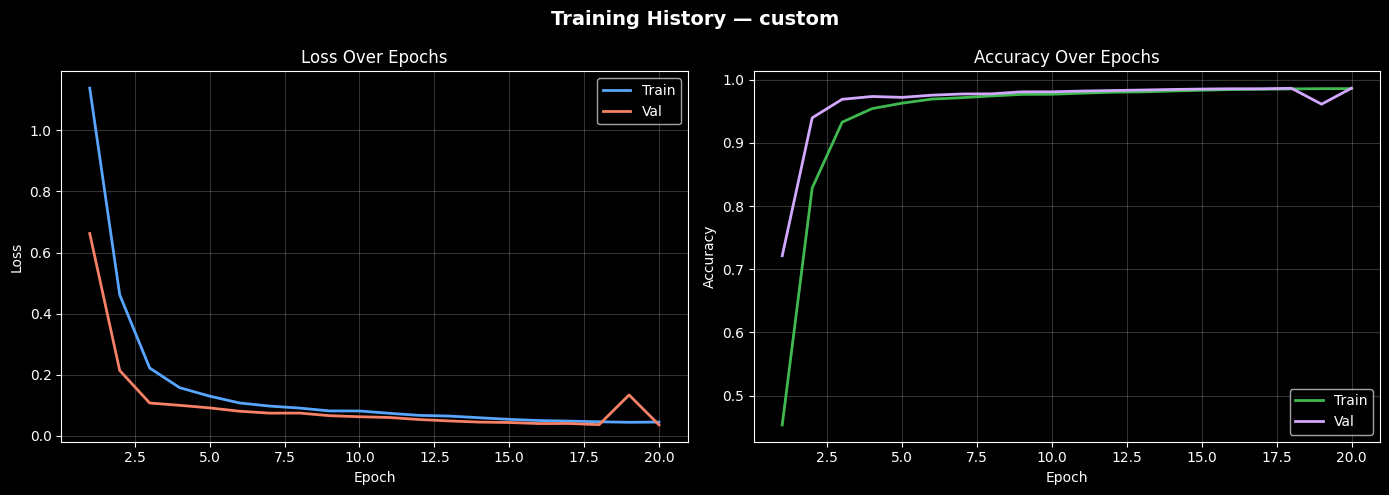

In [105]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

plt.style.use('dark_background')

# Training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs_x = range(1, len(history['train_loss']) + 1)
ax1.plot(epochs_x, history['train_loss'], label='Train', color='#58a6ff', lw=2)
ax1.plot(epochs_x, history['val_loss'], label='Val', color='#f78166', lw=2)
ax1.set_title('Loss Over Epochs'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.legend(); ax1.grid(alpha=0.2)
ax2.plot(epochs_x, history['train_acc'], label='Train', color='#3fb950', lw=2)
ax2.plot(epochs_x, history['val_acc'], label='Val', color='#d2a8ff', lw=2)
ax2.set_title('Accuracy Over Epochs'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.legend(); ax2.grid(alpha=0.2)
plt.suptitle(f'Training History — {DATASET_NAME}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'training_history_{DATASET_NAME}.png', dpi=120, bbox_inches='tight')
plt.show()


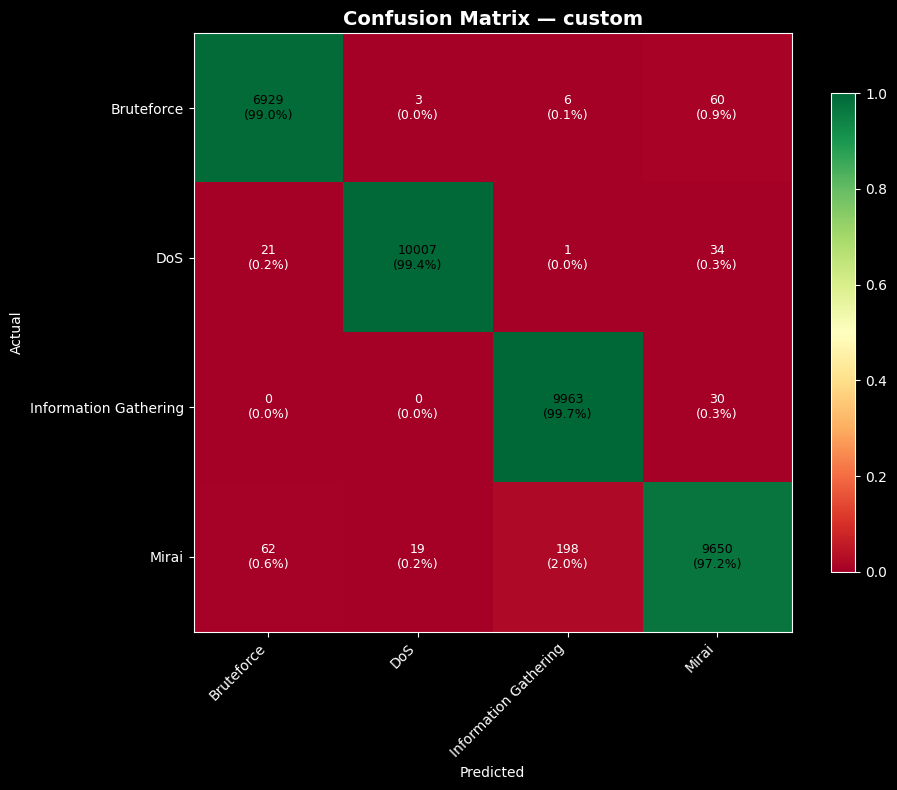

In [106]:
# Confusion matrix
cm = confusion_matrix(y_test, test_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm_norm, cmap='RdYlGn', vmin=0, vmax=1)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = 'white' if cm_norm[i,j] < 0.5 else 'black'
        ax.text(j, i, f'{cm[i,j]}\n({cm_norm[i,j]:.1%})',
                ha='center', va='center', color=color, fontsize=9)
ax.set_xticks(range(len(data['class_names'])))
ax.set_yticks(range(len(data['class_names'])))
ax.set_xticklabels(data['class_names'], rotation=45, ha='right')
ax.set_yticklabels(data['class_names'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — {DATASET_NAME}', fontsize=14, fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.savefig(f'confusion_matrix_{DATASET_NAME}.png', dpi=120, bbox_inches='tight')
plt.show()


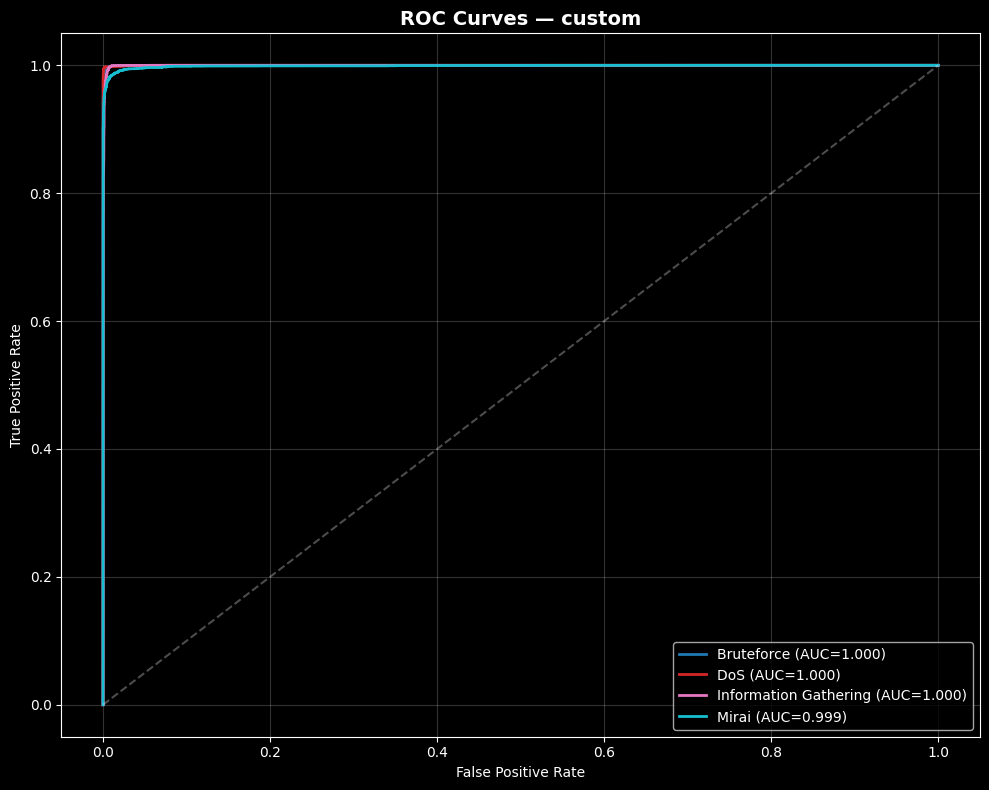

In [107]:
# ROC curves (one-vs-rest)
fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.tab10(np.linspace(0, 1, n_classes))
for i, name in enumerate(data['class_names']):
    y_bin = (y_test == i).astype(int)
    if test_proba.shape[1] > i and y_bin.sum() > 0:
        fpr, tpr, _ = roc_curve(y_bin, test_proba[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=colors[i], lw=2, label=f'{name} (AUC={roc_auc:.3f})')
ax.plot([0,1], [0,1], 'w--', alpha=0.3)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title(f'ROC Curves — {DATASET_NAME}', fontsize=14, fontweight='bold')
ax.legend(loc='lower right'); ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(f'roc_curves_{DATASET_NAME}.png', dpi=120, bbox_inches='tight')
plt.show()


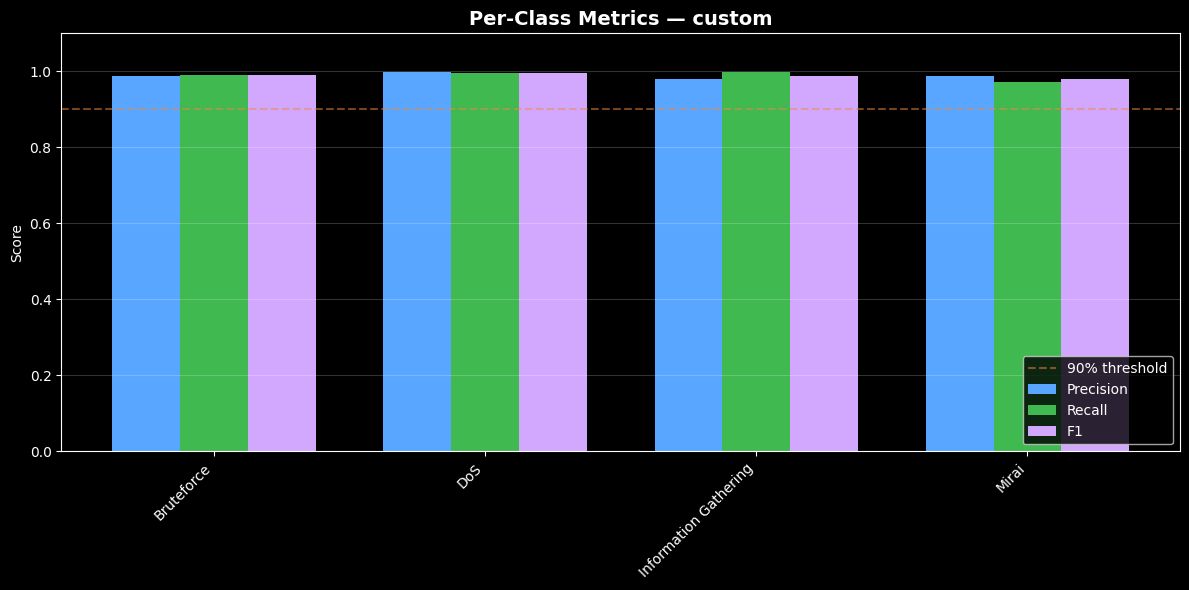

In [108]:
# Per-class F1 bar chart
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(data['class_names']))
width = 0.25
ax.bar(x - width, prec, width, label='Precision', color='#58a6ff')
ax.bar(x,         rec,  width, label='Recall',    color='#3fb950')
ax.bar(x + width, f1,   width, label='F1',        color='#d2a8ff')
ax.axhline(y=0.9, color='#f0883e', linestyle='--', alpha=0.5, label='90% threshold')
ax.set_xticks(x); ax.set_xticklabels(data['class_names'], rotation=45, ha='right')
ax.set_ylim(0, 1.1); ax.set_ylabel('Score')
ax.set_title(f'Per-Class Metrics — {DATASET_NAME}', fontsize=14, fontweight='bold')
ax.legend(loc='lower right'); ax.grid(alpha=0.2, axis='y')
plt.tight_layout()
plt.savefig(f'class_metrics_{DATASET_NAME}.png', dpi=120, bbox_inches='tight')
plt.show()


## 10. Save results

Saves the model, metrics, and a results summary to Colab's local storage.
Download these to compare across datasets.


In [110]:
# Save everything
out_dir = f'results_v2{DATASET_NAME}'
os.makedirs(out_dir, exist_ok=True)

# Model weights
torch.save(model.state_dict(), f'{out_dir}/model.pth')

# Metrics summary
results = {
    'dataset': DATASET_NAME,
    'mode': MODE,
    'accuracy': float(acc),
    'macro_f1': float(macro_f1),
    'weighted_f1': float(weighted_f1),
    'n_classes': n_classes,
    'class_names': data['class_names'],
    'per_class': {
        name: {
            'precision': float(prec[i]),
            'recall': float(rec[i]),
            'f1': float(f1[i]),
            'support': int(support[i]),
        }
        for i, name in enumerate(data['class_names'])
    },
    'history': {k: [float(x) for x in v] for k, v in history.items()},
    'training_samples': int(len(data['X_train'])),
    'test_samples': int(len(data['X_test'])),
}

with open(f'{out_dir}/results.json', 'w') as f:
    json.dump(results, f, indent=2)

# Save scaler too
import pickle
with open(f'{out_dir}/scaler.pkl', 'wb') as f:
    pickle.dump(data['scaler'], f)

print(f'Saved to {out_dir}/')
print('Files:')
for f in os.listdir(out_dir):
    size = os.path.getsize(os.path.join(out_dir, f)) / 1024
    print(f'  {size:>8.1f} KB  {f}')


Saved to results_v2custom/
Files:
      47.4 KB  model.pth
       3.2 KB  results.json
       1.8 KB  scaler.pkl
